## Exploratory Data Analysis
1. Destribution of Make and Female
   - Bar Chart
   - Pie Chart
2. What destribution of size of all images?
   - Histogram
   - Box Plot
   - Split by 'Gender'
3. Make the decision of width and height to resize using above chart
4. Remove the images that have inapropriate size

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob

In [3]:
# Extract path of male and female in crop_data folder and pu them into the list
fpath = glob('./data/crop_data/female/*.jpg')
mpath = glob('./data/crop_data/male/*.jpg')

In [4]:
df_fmale = pd.DataFrame(fpath, columns=['filepath'])
df_fmale['gender'] = 'female'

df_male = pd.DataFrame(mpath, columns=['filepath'])
df_male['gender'] = 'male'

df = pd.concat((df_fmale, df_male), axis=0)

df.head()

,filepath,gender
0,./data/crop_data/female\female_0.jpg,female
1,./data/crop_data/female\female_1.jpg,female
2,./data/crop_data/female\female_100.jpg,female
3,./data/crop_data/female\female_1002.jpg,female
4,./data/crop_data/female\female_1005.jpg,female


In [5]:
df.tail()

,filepath,gender
2311,./data/crop_data/male\male_994.jpg,male
2312,./data/crop_data/male\male_996.jpg,male
2313,./data/crop_data/male\male_997.jpg,male
2314,./data/crop_data/male\male_998.jpg,male
2315,./data/crop_data/male\male_999.jpg,male


In [6]:
df.shape

(5020, 2)

In [7]:
# Take an image path and return width of image
def get_size(path):
    img = cv2.imread(path)
    return img.shape[0]

In [8]:
df['dimension'] = df['filepath'].apply(get_size) #store deminsion of image in this column

In [9]:
df.head()

,filepath,gender,dimension
0,./data/crop_data/female\female_0.jpg,female,273
1,./data/crop_data/female\female_1.jpg,female,182
2,./data/crop_data/female\female_100.jpg,female,122
3,./data/crop_data/female\female_1002.jpg,female,122
4,./data/crop_data/female\female_1005.jpg,female,182


In [10]:
dist_gender = df['gender'].value_counts()
print(dist_gender)

gender
female    2704
male      2316
Name: count, dtype: int64


<Axes: >

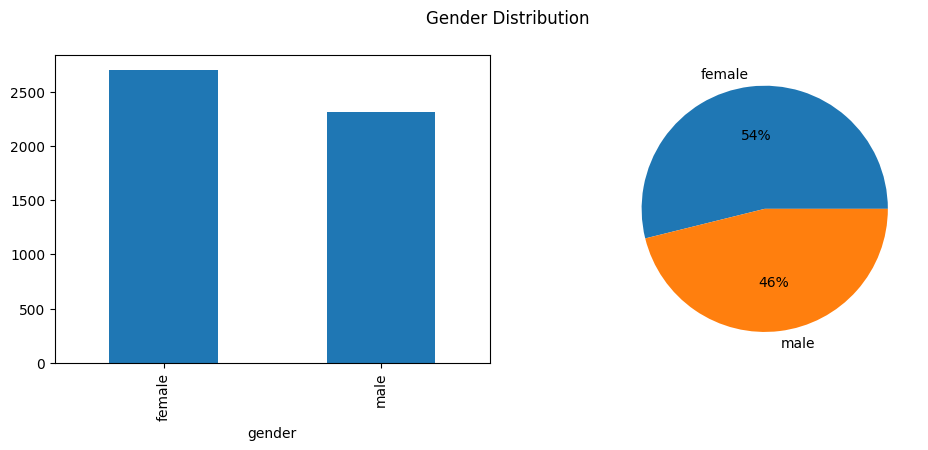

In [11]:
fig,ax = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(10, 4)
fig.suptitle("Gender Distribution")
fig.tight_layout()
dist_gender.plot(kind='bar', ax=ax[0])
dist_gender.plot(kind='pie', ax=ax[1], autopct='%0.0f%%')

What destribution of size of all images?
Histogram
Box Plot
Split by 'Gender'

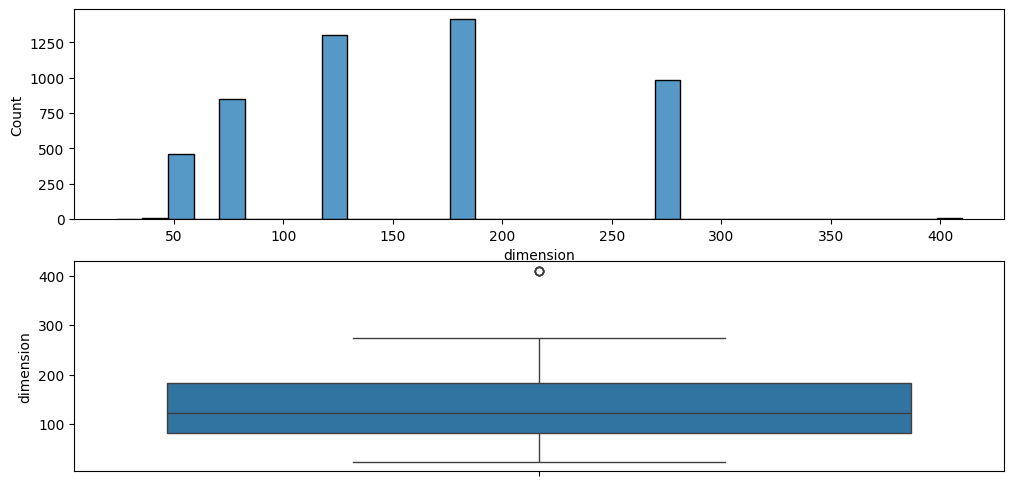

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
sns.histplot(df['dimension'])

plt.subplot(2,1,2)
sns.boxplot(df['dimension'])

plt.show()

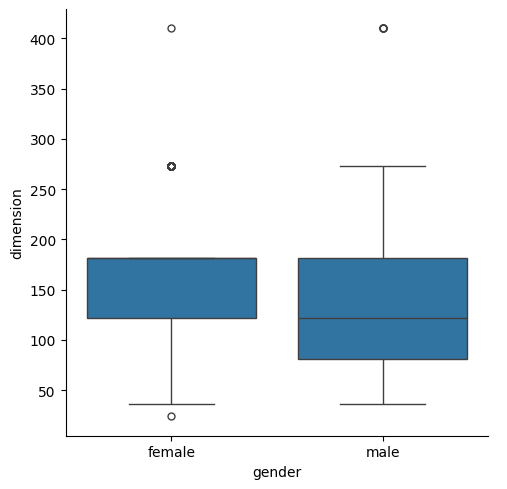

In [13]:
sns.catplot(data=df, x='gender', y='dimension', kind='box')

**Resize all images 100 X 100

In [14]:
df_filter = df.query('dimension > 60')

In [15]:
df_filter.shape

(4551, 3)

In [16]:
df_filter['gender'].value_counts(normalize=True)

gender
female    0.543177
male      0.456823
Name: proportion, dtype: float64

### Structure images
 - 100 x 100

In [17]:
def structuring(path):
    try:
        #read image
        img = cv2.imread(path)
        
        # convert into grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        #resize the imahge 100x100
        size = gray.shape[0]
        if size >= 100:
            gray_resize = cv2.resize(gray, (100, 100), cv2.INTER_AREA)
        else:
            gray_resize = cv2.resize(gray, (100, 100), cv2.INTER_CUBIC)
    
    
        #Flatten image
        flatten_image = gray_resize.flatten()
    
        return flatten_image
    except:
        return None

In [18]:
df_filter['data'] = df_filter['filepath'].apply(structuring)

In [19]:
df_filter.head()

,filepath,gender,dimension,data
0,./data/crop_data/female\female_0.jpg,female,273,"[188, 182, 182, 185, 174, 181, 192, 180, 217, ..."
1,./data/crop_data/female\female_1.jpg,female,182,"[32, 23, 31, 27, 28, 30, 28, 33, 36, 30, 46, 8..."
2,./data/crop_data/female\female_100.jpg,female,122,"[49, 49, 35, 34, 42, 40, 35, 39, 71, 62, 46, 4..."
3,./data/crop_data/female\female_1002.jpg,female,122,"[132, 121, 118, 97, 85, 92, 91, 110, 155, 162,..."
4,./data/crop_data/female\female_1005.jpg,female,182,"[234, 234, 234, 228, 231, 205, 122, 98, 74, 54..."


In [20]:
data = df_filter['data'].apply(pd.Series)

In [21]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,188,182,182,185,174,181,192,180,217,218,...,109,111,115,116,122,116,120,119,117,110
1,32,23,31,27,28,30,28,33,36,30,...,58,47,27,34,22,27,23,37,63,18
2,49,49,35,34,42,40,35,39,71,62,...,210,230,231,237,238,230,220,212,210,208
3,132,121,118,97,85,92,91,110,155,162,...,161,111,62,62,66,81,90,100,108,113
4,234,234,234,228,231,205,122,98,74,54,...,243,243,237,237,239,237,236,241,238,240


In [22]:
data.columns = [f'pixel_{i}' for i in data.columns]

In [23]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9990,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999
0,188,182,182,185,174,181,192,180,217,218,...,109,111,115,116,122,116,120,119,117,110
1,32,23,31,27,28,30,28,33,36,30,...,58,47,27,34,22,27,23,37,63,18
2,49,49,35,34,42,40,35,39,71,62,...,210,230,231,237,238,230,220,212,210,208
3,132,121,118,97,85,92,91,110,155,162,...,161,111,62,62,66,81,90,100,108,113
4,234,234,234,228,231,205,122,98,74,54,...,243,243,237,237,239,237,236,241,238,240


### Data normalization

In [24]:
data = data/255.0

In [25]:
data['gender'] = df_filter['gender']

In [26]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999,gender
0,0.737255,0.713725,0.713725,0.725490,0.682353,0.709804,0.752941,0.705882,0.850980,0.854902,...,0.435294,0.450980,0.454902,0.478431,0.454902,0.470588,0.466667,0.458824,0.431373,female
1,0.125490,0.090196,0.121569,0.105882,0.109804,0.117647,0.109804,0.129412,0.141176,0.117647,...,0.184314,0.105882,0.133333,0.086275,0.105882,0.090196,0.145098,0.247059,0.070588,female
2,0.192157,0.192157,0.137255,0.133333,0.164706,0.156863,0.137255,0.152941,0.278431,0.243137,...,0.901961,0.905882,0.929412,0.933333,0.901961,0.862745,0.831373,0.823529,0.815686,female
3,0.517647,0.474510,0.462745,0.380392,0.333333,0.360784,0.356863,0.431373,0.607843,0.635294,...,0.435294,0.243137,0.243137,0.258824,0.317647,0.352941,0.392157,0.423529,0.443137,female
4,0.917647,0.917647,0.917647,0.894118,0.905882,0.803922,0.478431,0.384314,0.290196,0.211765,...,0.952941,0.929412,0.929412,0.937255,0.929412,0.925490,0.945098,0.933333,0.941176,female


### Remove missing values

In [27]:
data.isnull().sum().sum()

np.int64(0)

In [28]:
data.dropna(inplace=True)

In [29]:
data.shape

(4551, 10001)

### Save the data

In [30]:
import pickle
pickle.dump(data, open('./data/data_images_100_100.pickle', mode='wb')) 